In [42]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/keplersmachines/kepler-labelled-time-series-data/exoTest.csv
/kaggle/input/datasets/keplersmachines/kepler-labelled-time-series-data/exoTrain.csv


**Hunting Exoplanets With ML**

We're Using Kepler Space Telescope Data And The Method For Detection Used Is Transit Photometery

In [43]:
#Importing Necessary Libraries And Modules 
import numpy as np, pandas as pd
import matplotlib.pyplot as plt , seaborn as sns
plt.style.use('fivethirtyeight')
#To Filter Out Unnecessary Warnings
import warnings
warnings.filterwarnings('ignore')

In [44]:
df_train=pd.read_csv('/kaggle/input/datasets/keplersmachines/kepler-labelled-time-series-data/exoTrain.csv')
df_train.head()
#Output-> The Luminous Flux Values Of Stars At Different Time Intervals.

,LABEL,FLUX.1,FLUX.2,FLUX.3,FLUX.4,FLUX.5,FLUX.6,FLUX.7,FLUX.8,FLUX.9,...,FLUX.3188,FLUX.3189,FLUX.3190,FLUX.3191,FLUX.3192,FLUX.3193,FLUX.3194,FLUX.3195,FLUX.3196,FLUX.3197
0,2,93.85,83.81,20.10,-26.98,-39.56,-124.71,-135.18,-96.27,-79.89,...,-78.07,-102.15,-102.15,25.13,48.57,92.54,39.32,61.42,5.08,-39.54
1,2,-38.88,-33.83,-58.54,-40.09,-79.31,-72.81,-86.55,-85.33,-83.97,...,-3.28,-32.21,-32.21,-24.89,-4.86,0.76,-11.70,6.46,16.00,19.93
2,2,532.64,535.92,513.73,496.92,456.45,466.00,464.50,486.39,436.56,...,-71.69,13.31,13.31,-29.89,-20.88,5.06,-11.80,-28.91,-70.02,-96.67
3,2,326.52,347.39,302.35,298.13,317.74,312.70,322.33,311.31,312.42,...,5.71,-3.73,-3.73,30.05,20.03,-12.67,-8.77,-17.31,-17.35,13.98
4,2,-1107.21,-1112.59,-1118.95,-1095.10,-1057.55,-1034.48,-998.34,-1022.71,-989.57,...,-594.37,-401.66,-401.66,-357.24,-443.76,-438.54,-399.71,-384.65,-411.79,-510.54


In [45]:
#Dimension Of The Training DataFrame
print(df_train.shape)
#Output->
'''
df_train[0]::Number Of Stars
df_train[1]::Respective Flux Values
'''

(5087, 3198)


'\ndf_train[0]::Number Of Stars\ndf_train[1]::Respective Flux Values\n'

In [46]:
#Checking For Missing Values In DataFrame
df_train[df_train.isnull().any(axis=1)]

,LABEL,FLUX.1,FLUX.2,FLUX.3,FLUX.4,FLUX.5,FLUX.6,FLUX.7,FLUX.8,FLUX.9,...,FLUX.3188,FLUX.3189,FLUX.3190,FLUX.3191,FLUX.3192,FLUX.3193,FLUX.3194,FLUX.3195,FLUX.3196,FLUX.3197


In [62]:
#Visualizing The Missing Values In The DataFrame
sns.heatmap(df_train.isnull())
'''
If The Dataset Had Any Null Values,There Would Be Some Horizontal Lines Present
In The Heatmap
'''

KeyboardInterrupt: 

In [48]:
#Number Of Labels Present In The DataFrame
df_train['LABEL'].unique()

array([2, 1])

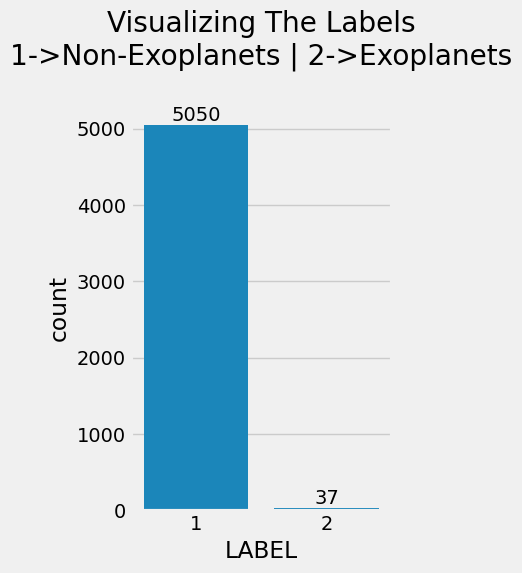

In [49]:
#Visualizing The Labels
plt.figure(figsize=(3,5))
ax=sns.countplot(x='LABEL',data=df_train)
ax.bar_label(ax.containers[0])
plt.title("Visualizing The Labels\n1->Non-Exoplanets | 2->Exoplanets\n")
plt.show()
#There's A Huge Imbalance In The Data

In [50]:
#For The Ease Of Binary Classification,We're Replacing The Labels
df_train=df_train.replace({'LABEL':{1:0,2:1}})
df_train['LABEL'].unique()

array([1, 0])

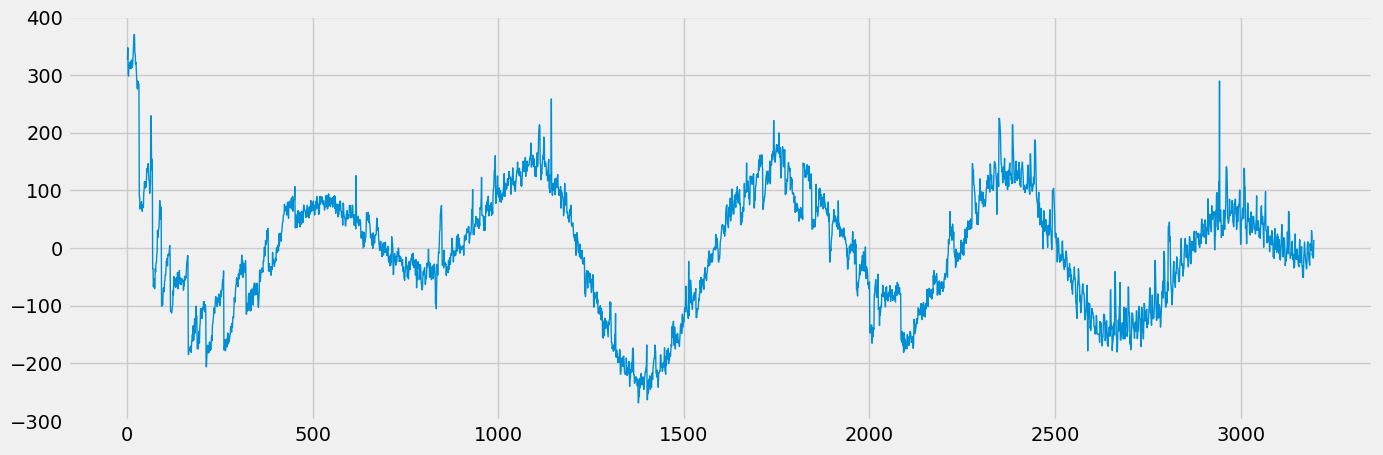

In [51]:
#Visualizing The Brightness Vs Time Curve
#Dropping Off The LABEL Column To Plot Only The Flux Values
df_plot=df_train.drop(['LABEL'],axis=1)
#Plotting A Random Star
time=range(1,3198)
flux=df_plot.iloc[3,:].values
plt.figure(figsize=(15,5))
plt.plot(time,flux,linewidth=1)


In [52]:
#Function For Plotting Flux Variation Of Star
def flux_plot(df,x,exo=True):
    color='b' if exo==True else 'm'
    plt.figure(figsize=(15,5))
    plt.plot(time,df.iloc[x-1],linewidth=.5,color=color)
    t1,c1=f"Flux Variation Of Star {x} With Exoplanents",'olive'
    t2,c2=f"Flux Variation Of Star {x} Without Exoplanets",'tab:red'
    plt.title(t1,color=c1) if exo==True else plt.title(t2,color=c2)
    plt.xlabel("Time")
    plt.ylabel("Flux Variation")

'\nThere Are Huge Spikes Especially With The Planets With No Exoplanets Which Can Be \nConsidered As Outliers Whose Flux Values Are More Than 0.25 x 10^6\n'

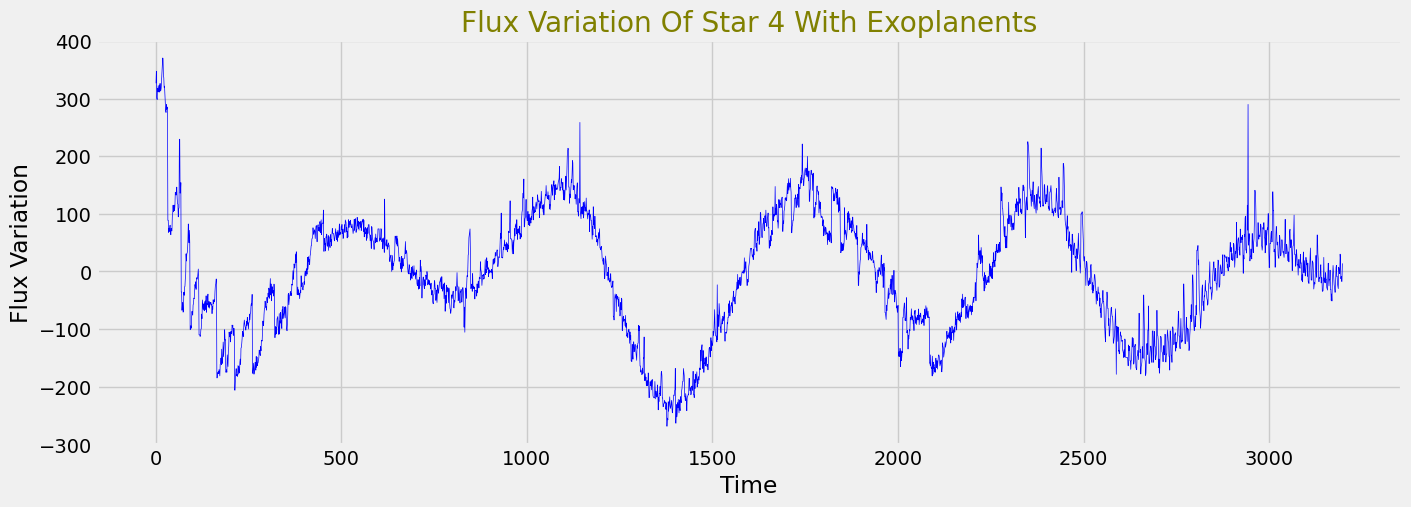

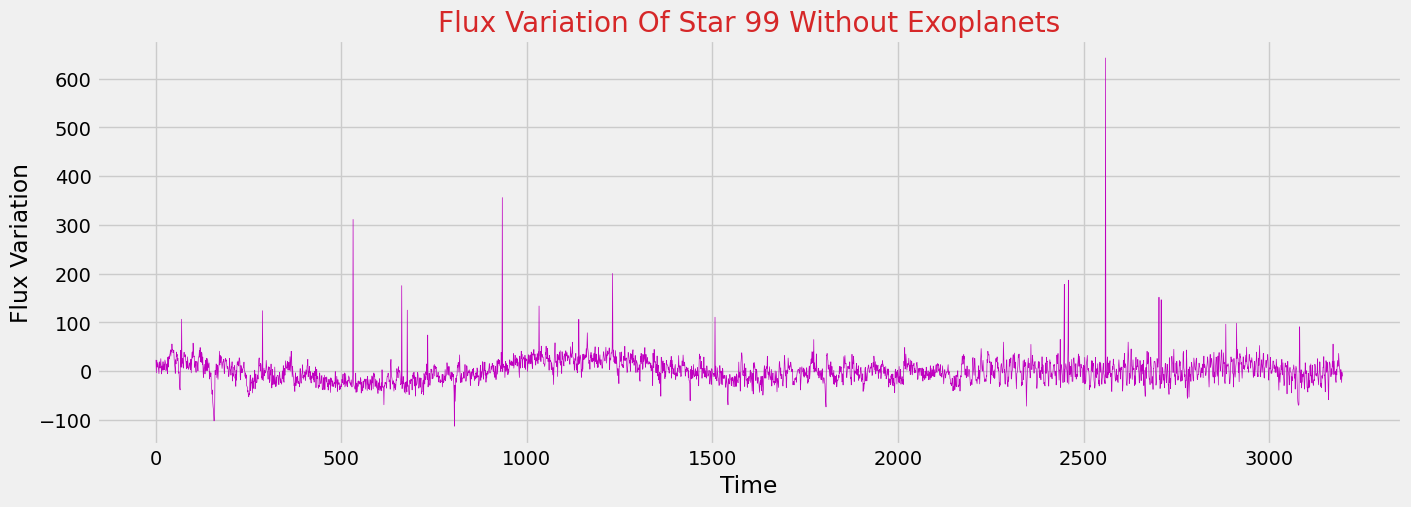

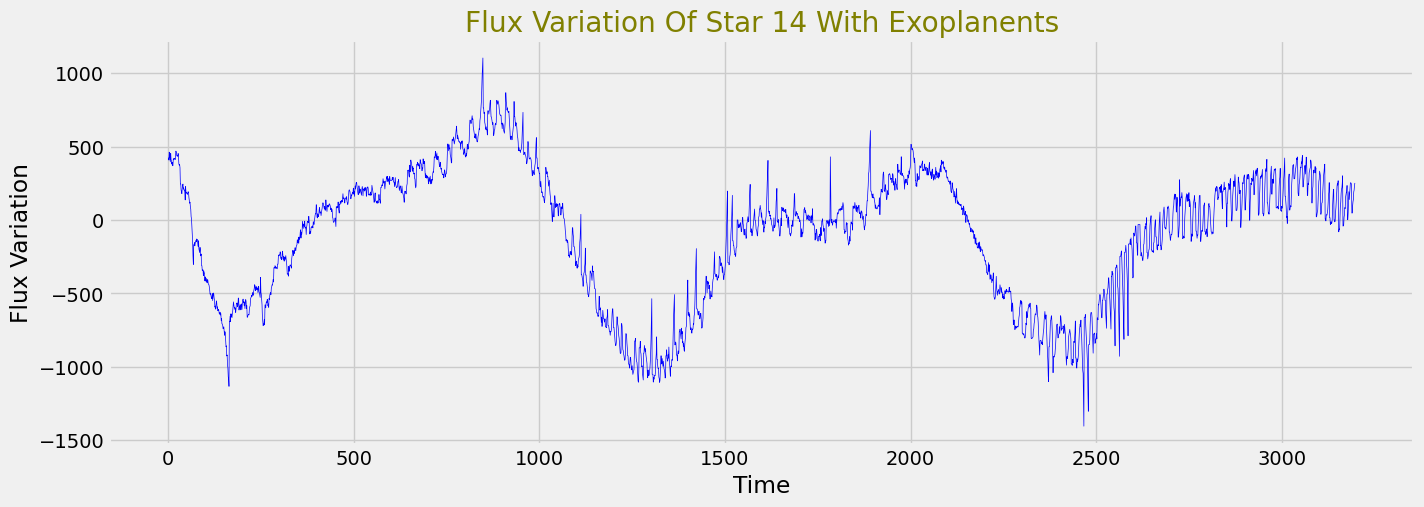

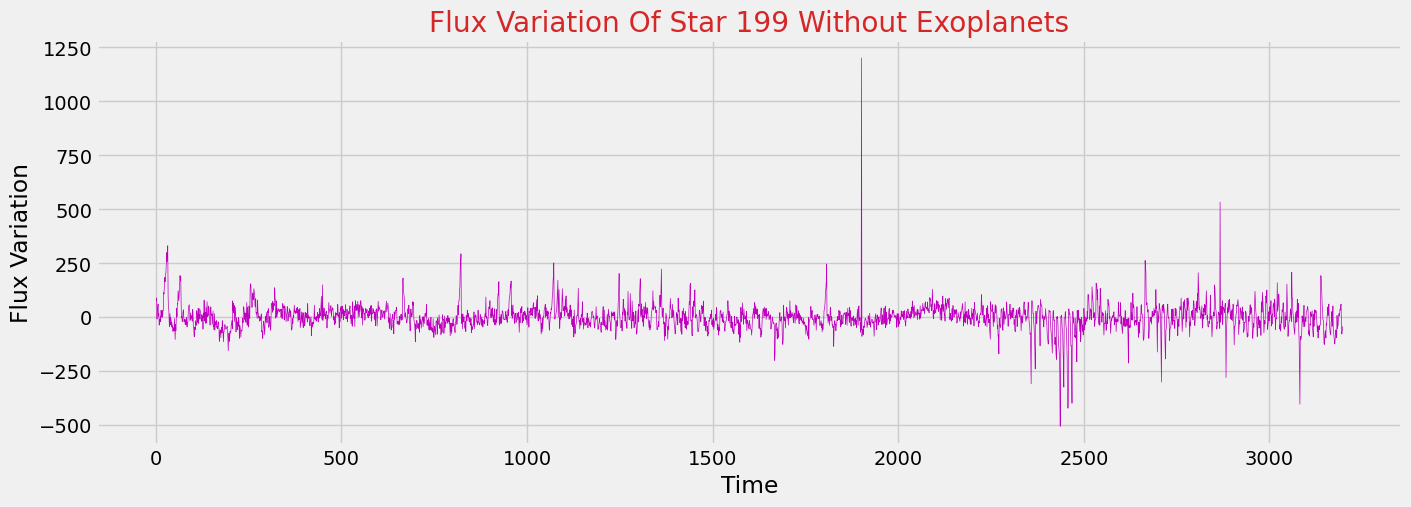

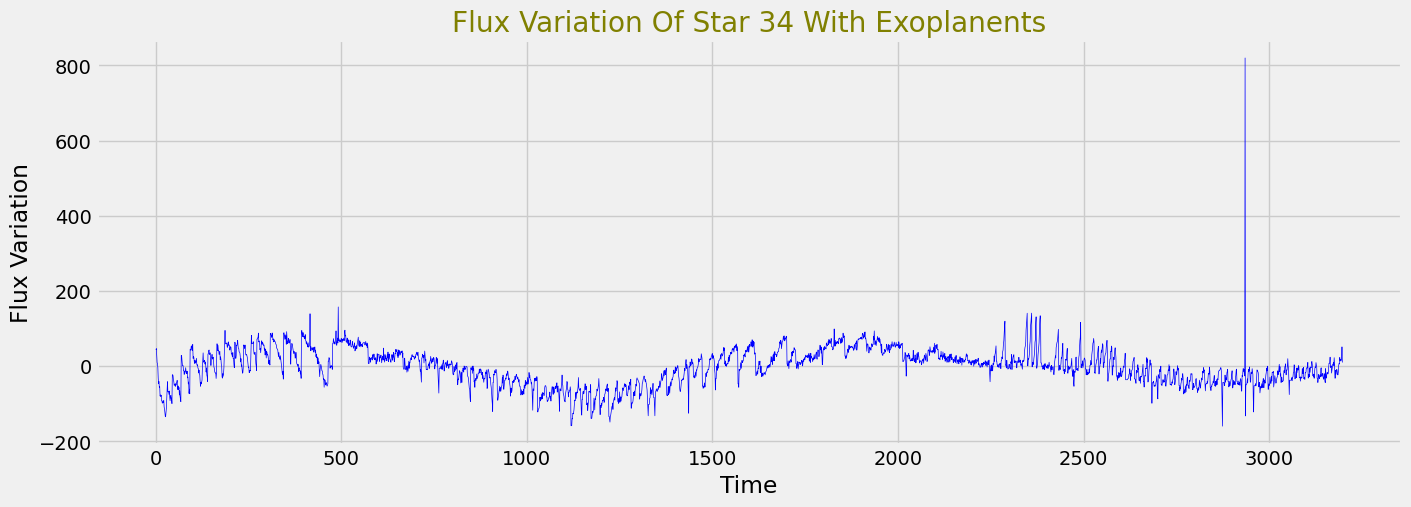

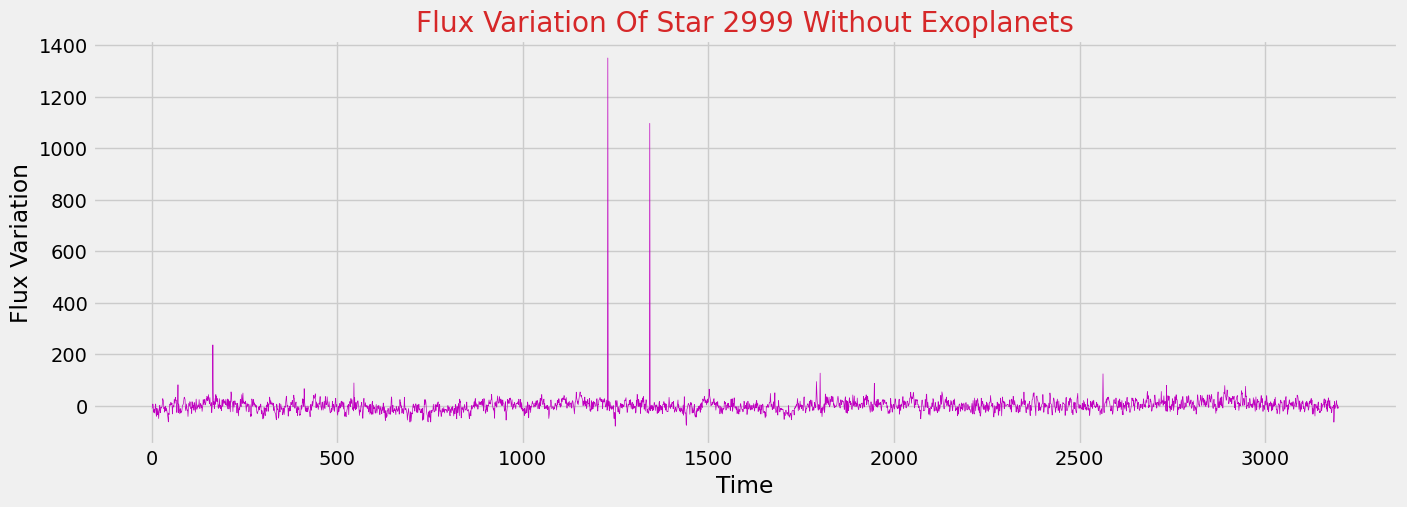

In [53]:
exo,n_exo=[4,14,34],[99,199,2999]
for i in range(len(exo)):
    flux_plot(df_plot,exo[i],exo=True)
    flux_plot(df_plot,n_exo[i],exo=False)
'''
There Are Huge Spikes Especially With The Planets With No Exoplanets Which Can Be 
Considered As Outliers Whose Flux Values Are More Than 0.25 x 10^6
'''

In [54]:
outliers=df_train[df_train['FLUX.2']>0.25e6]
df_train.drop(outliers.index,axis=0,inplace=True)
df_train

,LABEL,FLUX.1,FLUX.2,FLUX.3,FLUX.4,FLUX.5,FLUX.6,FLUX.7,FLUX.8,FLUX.9,...,FLUX.3188,FLUX.3189,FLUX.3190,FLUX.3191,FLUX.3192,FLUX.3193,FLUX.3194,FLUX.3195,FLUX.3196,FLUX.3197
0,1,93.85,83.81,20.10,-26.98,-39.56,-124.71,-135.18,-96.27,-79.89,...,-78.07,-102.15,-102.15,25.13,48.57,92.54,39.32,61.42,5.08,-39.54
1,1,-38.88,-33.83,-58.54,-40.09,-79.31,-72.81,-86.55,-85.33,-83.97,...,-3.28,-32.21,-32.21,-24.89,-4.86,0.76,-11.70,6.46,16.00,19.93
2,1,532.64,535.92,513.73,496.92,456.45,466.00,464.50,486.39,436.56,...,-71.69,13.31,13.31,-29.89,-20.88,5.06,-11.80,-28.91,-70.02,-96.67
3,1,326.52,347.39,302.35,298.13,317.74,312.70,322.33,311.31,312.42,...,5.71,-3.73,-3.73,30.05,20.03,-12.67,-8.77,-17.31,-17.35,13.98
4,1,-1107.21,-1112.59,-1118.95,-1095.10,-1057.55,-1034.48,-998.34,-1022.71,-989.57,...,-594.37,-401.66,-401.66,-357.24,-443.76,-438.54,-399.71,-384.65,-411.79,-510.54
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5082,0,-91.91,-92.97,-78.76,-97.33,-68.00,-68.24,-75.48,-49.25,-30.92,...,139.95,147.26,156.95,155.64,156.36,151.75,-24.45,-17.00,3.23,19.28
5083,0,989.75,891.01,908.53,851.83,755.11,615.78,595.77,458.87,492.84,...,-26.50,-4.84,-76.30,-37.84,-153.83,-136.16,38.03,100.28,-45.64,35.58
5084,0,273.39,278.00,261.73,236.99,280.73,264.90,252.92,254.88,237.60,...,-26.82,-53.89,-48.71,30.99,15.96,-3.47,65.73,88.42,79.07,79.43
5085,0,3.82,2.09,-3.29,-2.88,1.66,-0.75,3.85,-0.03,3.28,...,10.86,-3.23,-5.10,-4.61,-9.82,-1.50,-4.65,-14.55,-6.41,-2.55


Implementing KNN Algorithm For Classification Without Balancing The Data

In [55]:
x=df_train.drop(['LABEL'],axis=1)
y=df_train.LABEL

In [56]:
#Splitting The Dataset Into Train And Test Set
from sklearn.model_selection import train_test_split
#Using 30 Percent As Testing Set
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=0)

In [57]:
#Feature Scaling
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
x_train_sc=sc.fit_transform(x_train)
x_test_sc=sc.transform(x_test)
#Checking The minimum, Mean And Maximum Value After Scaling
print("x_train After Scaling::\n")
print(f"Minimum:{round(np.min(x_train_sc),2)}\nMean:{round(np.mean(x_train_sc),2)}\nMax:{round(np.max(x_train_sc),2)}\n")
print("x_test After Scaling ::\n")
print(f"Minimum:{round(np.min(x_test_sc),2)}\nMean:{round(np.mean(x_test_sc),2)}\nMax:{round(np.max(x_test_sc),2)}\n")

x_train After Scaling::

Minimum:-57.1
Mean:0.0
Max:59.46

x_test After Scaling ::

Minimum:-133.38
Mean:0.0
Max:112.18




Validation Accuracy Of KNN: 0.991480996068152


Classification Report:
               precision    recall  f1-score   support

           0       0.99      1.00      1.00      1513
           1       0.00      0.00      0.00        13

    accuracy                           0.99      1526
   macro avg       0.50      0.50      0.50      1526
weighted avg       0.98      0.99      0.99      1526



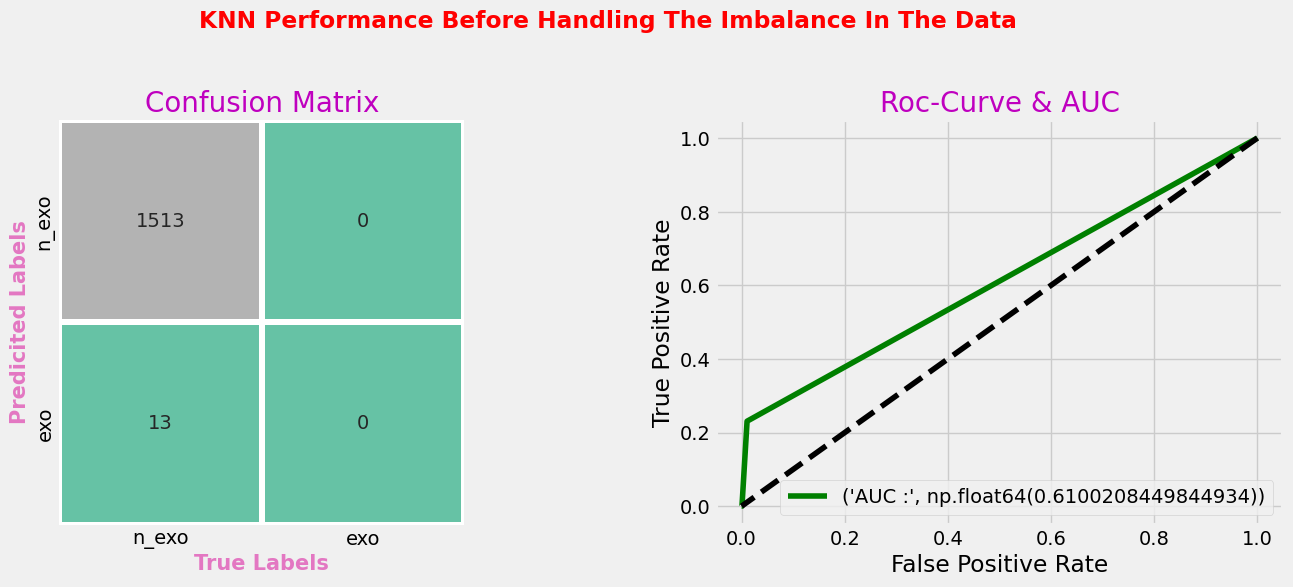

In [58]:
#Fitting The KNN Classifier On This Data
from sklearn.neighbors import KNeighborsClassifier as knc
#Choosing k=5
knn_classifier=knc(n_neighbors=5,metric='minkowski',p=2) 
knn_classifier.fit(x_train_sc,y_train)
#Predicting
pred=knn_classifier.predict(x_test_sc)

#Results
from sklearn.metrics import confusion_matrix,accuracy_score,classification_report,roc_curve,auc
print('\nValidation Accuracy Of KNN:',accuracy_score(y_test,pred))
print()
print ("\nClassification Report:\n",(classification_report(y_test,pred)))

#Confusion Matrix
plt.figure(figsize=(15,11))
plt.subplots_adjust(wspace=0.3)
plt.suptitle("KNN Performance Before Handling The Imbalance In The Data",color='r',weight='bold')
plt.subplot(221)
sns.heatmap(confusion_matrix(y_test,pred),annot=True,cmap="Set2",fmt="d",linewidths=3,cbar=False,
           xticklabels=['n_exo','exo'],yticklabels=['n_exo','exo'],square=True)
plt.xlabel("True Labels",fontsize=15,weight='bold',color='tab:pink')
plt.ylabel("Predicited Labels",fontsize=15,weight='bold',color='tab:pink')
plt.title("Confusion Matrix",fontsize=20,color='m')

#ROC Curve And AUC Plotting
prob=knn_classifier.predict_proba(x_test_sc)[:,1]
fpr,tpr,thresholds=roc_curve(y_test,prob)
plt.subplot(222)
plt.plot(fpr,tpr,label=("AUC :",auc(fpr,tpr)),color="g")
plt.plot([1,0],[1,0],"k--")
plt.legend()
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title("Roc-Curve & AUC",fontsize=20,color='m')
plt.show()

Handling The Imbalanced Dataset

Before Sampling:Counter({0: 5049, 1: 37})
After Sampling:Counter({1: 5049, 0: 5049})


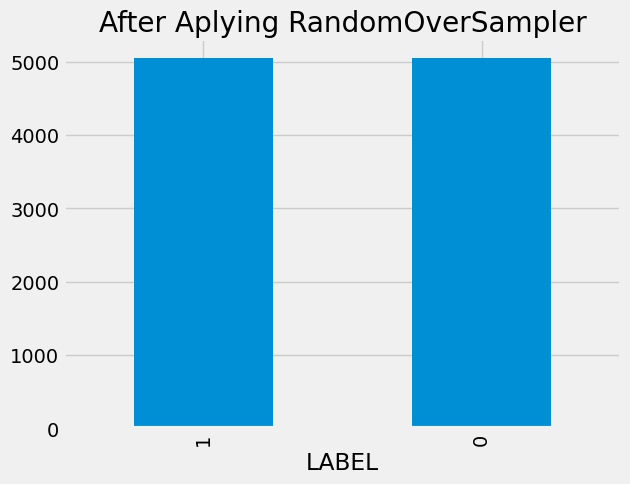

In [59]:
#We'll Be Using Random Over Sampling
'''
Random Over Sampling Is Over-Sampling By Duplicating Some Of The Original Samples
Of The Minority Class.
'''
from imblearn.over_sampling import RandomOverSampler
from collections import Counter
ros=RandomOverSampler()
x_ros,y_ros=ros.fit_resample(x,y)
print(f"Before Sampling:{Counter(y)}")
print(f"After Sampling:{Counter(y_ros)}")
#Visualizing The Over-Sampling
y_ros.value_counts().plot(kind='bar',title='After Aplying RandomOverSampler');

In [60]:
#Repeating Previous Steps 
x_train,x_test,y_train,y_test=train_test_split(x_ros,y_ros,test_size=0.3,random_state=0)
sc=StandardScaler()
x_train_sc=sc.fit_transform(x_train)
x_test_sc=sc.transform(x_test)



Validation Accuracy Of KNN: 0.9986798679867986


Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      1512
           1       1.00      1.00      1.00      1518

    accuracy                           1.00      3030
   macro avg       1.00      1.00      1.00      3030
weighted avg       1.00      1.00      1.00      3030



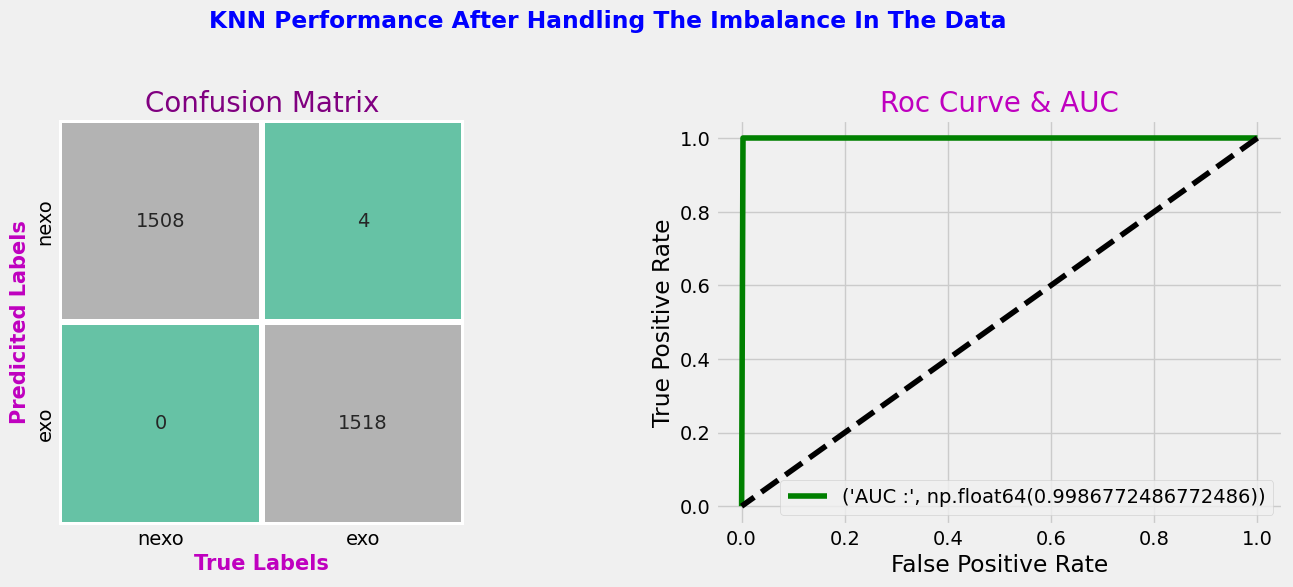

In [61]:
#Fiting The KNN Classifier Model After Handling The Imbalance
# Choosing K = 1
knn_classifier=knc(n_neighbors=1,metric='minkowski',p=2)  
knn_classifier.fit(x_train_sc,y_train)
#Prediction
pred=knn_classifier.predict(x_test_sc)

# Results
from sklearn.metrics import confusion_matrix,accuracy_score,classification_report,roc_curve,auc
print('\nValidation Accuracy Of KNN:',accuracy_score(y_test,pred))
print()
print ("\nClassification Report:\n",(classification_report(y_test,pred)))

#Confusion Matrix
plt.figure(figsize=(15,11))
plt.subplots_adjust(wspace=0.3)
plt.suptitle("KNN Performance After Handling The Imbalance In The Data",color='b',weight='bold')
plt.subplot(221)
sns.heatmap(confusion_matrix(y_test,pred),annot=True,cmap="Set2",fmt="d",linewidths=3,cbar=False,
           xticklabels=['nexo','exo'],yticklabels=['nexo','exo'],square=True)
plt.xlabel("True Labels",fontsize=15,weight='bold',color='m')
plt.ylabel("Predicited Labels",fontsize=15,weight='bold',color='m')
plt.title("Confusion Matrix",fontsize=20,color='purple')

#ROC curve and Area under the curve plotting
prob=knn_classifier.predict_proba(x_test_sc)[:,1]
fpr,tpr,thresholds=roc_curve(y_test,prob)
plt.subplot(222)
plt.plot(fpr,tpr,label=("AUC :",auc(fpr,tpr)),color="g")
plt.plot([1,0],[1,0],'k--')
plt.legend(loc="best")
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title("Roc Curve & AUC",fontsize=20,color='m')
plt.show()